/tmp/ipykernel_1206851/313142681.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.8, rect=[0, 0, 1, 0.96])


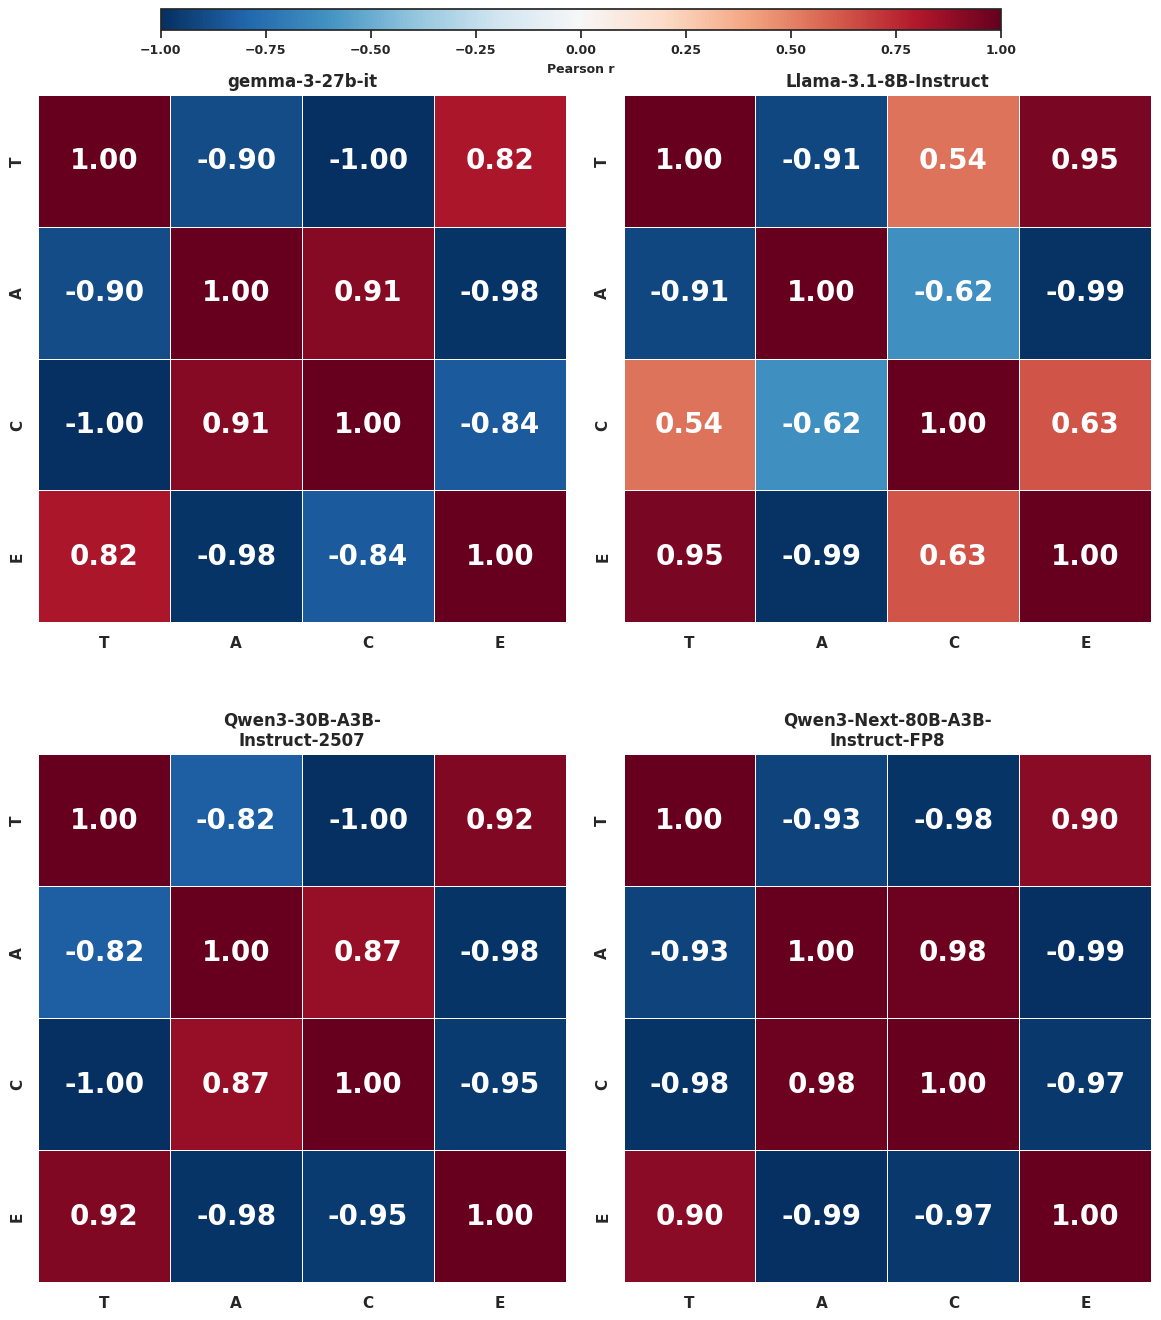

In [7]:
from pathlib import Path
import textwrap
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

folder_path = Path("output/result_without_rep_id")  # 替换为实际数据文件夹路径

MODEL_NAMES = [
    "gemma-3-27b-it",
    "Llama-3.1-8B-Instruct", 
    "Qwen3-30B-A3B-Instruct-2507",
    "Qwen3-Next-80B-A3B-Instruct-FP8",
]

data_paths = {}
for model in MODEL_NAMES:
    data_file = folder_path / f"metrics_by_question_judge_prompt_temp_{model}.jsonl"
    if not data_file.exists():
        raise FileNotFoundError(f"Missing data file: {data_file}")
    data_paths[model] = pd.read_json(data_file, lines=True)


COLUMN_MAP = {
    "temperature": "T",
    "Agreement (µ)": "A",
    "Consistency (µ)": "C", 
    "Error Rate (µ)": "E",
}
METRIC_COLUMNS = ["A", "C", "E"]
ANALYSIS_COLUMNS = ["T"] + METRIC_COLUMNS


temperature_summaries = {}
correlation_matrices = {}


for model_name, df in data_paths.items():
    df = df.rename(columns=COLUMN_MAP)
    temp_summary = (
        df.groupby("T", dropna=False)[METRIC_COLUMNS]
        .mean()
        .reset_index()
        .sort_values("T")
        .reset_index(drop=True)
    )
    temperature_summaries[model_name] = temp_summary
    correlation_matrices[model_name] = temp_summary[ANALYSIS_COLUMNS].corr()


# ---------------------------------------------------------------------------
# Visualisation: Compact 2×2 correlation heatmaps
# ---------------------------------------------------------------------------


sns.set_theme(style="white", font_scale=2.2)  # 增大全局字体缩放
plt.rcParams.update({'font.weight': 'bold', 'font.family': 'sans-serif'})  # 全局粗体


fig, axes = plt.subplots(2, 2, figsize=(12, 14))
axes = axes.flatten()


for idx, model_name in enumerate(MODEL_NAMES):
    ax = axes[idx]
    corr = correlation_matrices[model_name]
    
    sns.heatmap(
        corr,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.7,
        cbar=False,
        annot_kws={"fontsize": 20, "weight": "bold"},  # 矩阵内部文字增大到16，并粗体
    )


    ax.set_title(textwrap.fill(model_name, width=22), fontsize=12, fontweight="bold")
    ax.tick_params(axis="both", labelsize=11)
    # 轴标签粗体
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')


# colorbar部分
cbar_ax = fig.add_axes([0.15, 0.95, 0.7, 0.015])
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=-1, vmax=1))
sm.set_array([])


cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', 
                   shrink=0.7, pad=0.01)
cbar.ax.tick_params(labelsize=9)
# colorbar刻度粗体
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')
cbar.set_label("Pearson r", fontweight="bold", fontsize=9)




plt.tight_layout(pad=0.8, rect=[0, 0, 1, 0.96])
fig.savefig("temperature_metric_correlation_heatmaps_TACE.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [4]:
import pandas as pd

model_name = "gemma-3-27b-it"
df = pd.read_json(f"output/result_without_rep_id/metrics_by_question_judge_prompt_temp_{model_name}.jsonl",lines=True)

In [6]:
df

,question_id,judge_type,prompt_variant,temperature,n_rows,Agreement (µ),Consistency (µ),Error Rate (µ)
0,0,pairwise,baseline,0.01,10,0.000000,1.000000,0.0
1,0,pairwise,baseline,0.50,10,0.000000,1.000000,0.0
2,0,pairwise,baseline,1.00,10,0.000000,1.000000,0.0
3,0,pairwise,baseline,1.50,10,0.000000,1.000000,0.0
4,0,pairwise,baseline,2.00,10,0.000000,1.000000,0.0
...,...,...,...,...,...,...,...,...
17995,499,single_answer,cot,0.50,10,1.000000,1.000000,0.0
17996,499,single_answer,cot,1.00,10,1.000000,1.000000,0.0
17997,499,single_answer,cot,1.50,10,1.000000,1.000000,0.0
17998,499,single_answer,cot,2.00,10,0.888889,0.875000,0.1
